In [13]:
import sys
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from testers.classical_solve_lin_program import solve_lp # type: ignore[reportMissingImports]
from testers.classical_solve_quad_program import solve_qcp # type: ignore[reportMissingImports]
import matplotlib.pyplot as plt

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [15]:
# Number of copies of the network in the toy system
N=20

# Whether the production and flow variables have upper bounds
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=True

# Capacity / demand parameters
# GAMMA=1.0
GAMMA=1.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 20

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = True

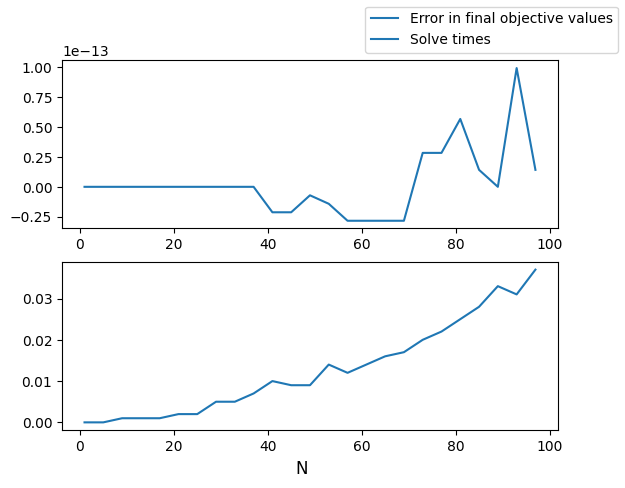

In [23]:
errors = []
times = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    quad, q_time = solve_qcp(f_name="toy.json")
    if val is not None:
        errors.append(val - n)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("N")
ax1.plot(n_range, errors, label="Error in final objective values")
ax2.plot(n_range, times, label="Solve times")
fig.legend()

20
60
100
140
180
220
260
300
340
380
420
460
500


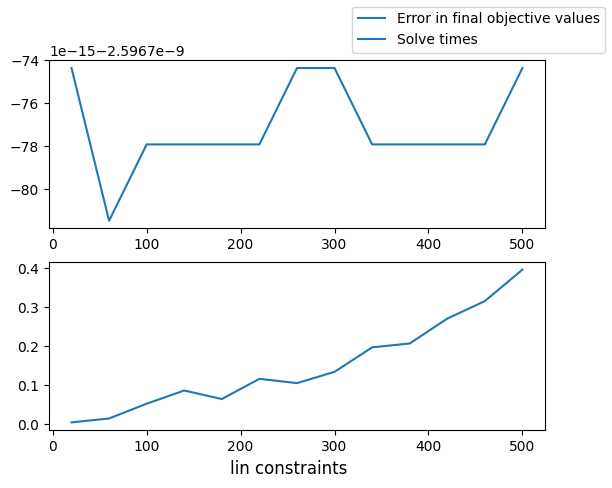

In [10]:
errors = []
times = []
toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                    EPS, DELTA, LP, LF, UP)
quad, q_time = solve_qcp(f_name="toy.json")

# lin_cons_range = range(1, 101, 4)
lin_cons_range = range(20, 501, 40)
for lin_cons in lin_cons_range:
    print(lin_cons)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=REMOVE_DIVISION)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    if val is not None:
        errors.append(val - quad)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

In [11]:
print(errors)

[-2.5967743511046137e-09, -2.5967814565319713e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967743511046137e-09, -2.5967743511046137e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967779038182925e-09, -2.5967743511046137e-09]


In [9]:
# Put the original QCP into gurobi
qcp_value, qcp_time = solve_qcp(f_name="model11_quad_reform_nofix.json")
print(qcp_value, qcp_time)

2914.0372553299326 0.0009999275207519531


In [10]:
print(solve_lp(f_name="Model11_lp_nofix.json"))
print(solve_qcp(f_name="Model11_lp_nofix.json"))

(2730.754328545064, 0.006000041961669922)
(2730.754328544699, 0.0019998550415039062)


-0.01997839325622408
-1.4336252510511258


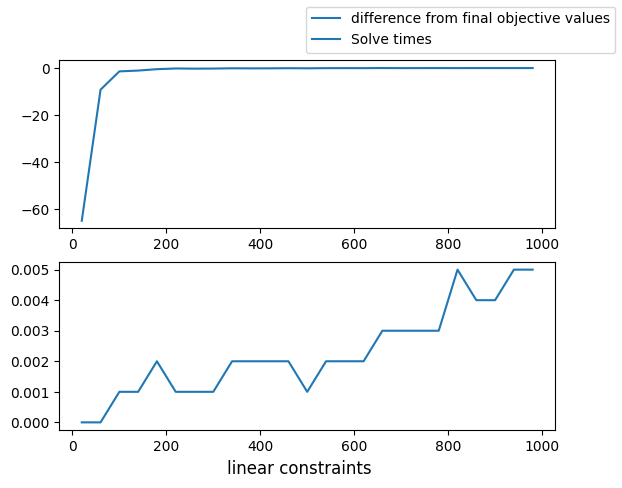

In [11]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_nofix.json")
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-0.019978393256678828
-1.4336252510511258


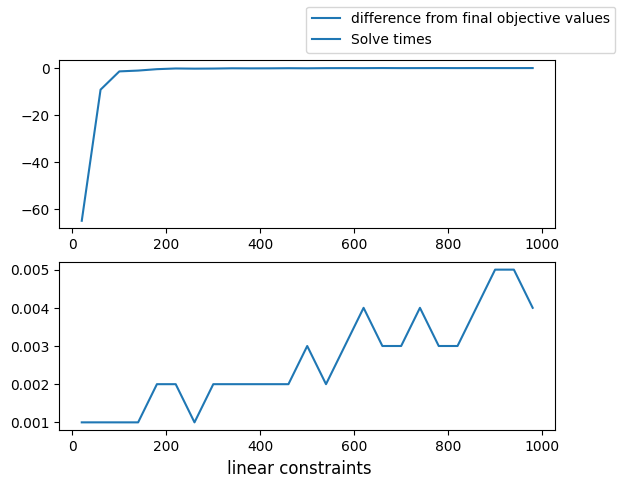

In [12]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        f_name="model11_quad_reform_nofix.json")
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

# Testing with linear relaxation of nonconvex problem

In [ ]:
errors = []
times = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP, convex_relax=False, f_out="toy_unrelaxed.json")
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, f_name="toy_unrelaxed.json")
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, f_name="toy_unrelaxed.json")
    val, time = solve_lp()
    if val is not None:
        errors.append(val - n)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("N")
ax1.plot(n_range, errors, label="Error in final objective values")
ax2.plot(n_range, times, label="Solve times")
fig.legend()

NameError: name 'X_UPPER_BOUNDS' is not defined

In [ ]:
errors = []
times = []
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, , F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP, convex_relax=False, f_out="toy_unrelaxed.json")
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, f_name="toy_unrelaxed.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, f_name="toy_unrelaxed.json")
    val, time = solve_lp()
    if val is not None:
        errors.append(val - n)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

In [ ]:
quadratic_model_lin_approx(1000, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                            SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, f_name="model11_quad.json")
val, time = solve_lp()
print(val, time)

In [ ]:
quadratic_model_lin_approx(1000, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                            SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, f_name="model11_quad_unrelaxed.json")
val, time = solve_lp()
print(val, time)